In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [63]:
CSV = "/Users/user/data/research/proton-deuteron/csv/length.csv"

In [78]:
df = pd.read_csv(CSV)

In [88]:
df

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass
0,8675,12,1249,1,0,31.53803,1,0,1082.47681
1,8675,12,1250,23,0,27.51520,0,0,120.62389
2,8675,12,1250,23,1,7.06335,0,0,120.62389
3,8675,12,1250,23,2,18.30797,0,0,120.62389
4,8675,12,1250,23,3,12.67128,0,0,120.62389
...,...,...,...,...,...,...,...,...,...
3983859,9781,133,21623,7,2,52.07600,0,0,-70.84017
3983860,9781,133,21623,7,3,77.36593,0,0,-70.84017
3983861,9781,133,21623,7,4,10.73799,0,0,-70.84017
3983862,9781,133,21623,7,5,5.38976,0,0,-70.84017


In [87]:
unique = df[['run', 'subrun', 'event']].drop_duplicates()
unique

,run,subrun,event
0,8675,12,1249
1,8675,12,1250
24,8675,12,1256
26,8675,12,1257
28,8675,12,1258
...,...,...,...
3983847,9781,133,21589
3983849,9781,133,21596
3983851,9781,133,21614
3983855,9781,133,21621


In [89]:
selection = df[(df['wctrk_picky'] == 1) & (df['ntracks_reco'] == 1) & (df['beamline_mass'] > 600) & (df['beamline_mass'] < 1600)]

In [90]:
selection

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass
171,8675,12,1310,1,0,54.19858,0,1,937.34863
436,8675,15,1662,1,0,13.63823,0,1,894.94031
659,8675,30,3415,1,0,1.23029,0,1,942.88965
1035,8675,38,4280,1,0,81.66306,0,1,1046.43018
1152,8675,40,4480,1,0,2.11446,0,1,892.57971
...,...,...,...,...,...,...,...,...,...
3982206,9781,103,16997,1,0,22.35578,1,1,1030.53992
3982627,9781,109,17945,1,0,22.24012,1,1,892.56842
3982671,9781,109,17974,1,0,5.52662,1,1,950.14380
3982906,9781,112,18441,1,0,31.67954,1,1,997.18292


In [101]:
events = selection[['run', 'subrun', 'event']].drop_duplicates().reset_index(drop=True)
events.to_csv('/Users/user/data/research/proton-deuteron/csv/picky_1track_protons.csv', index=False)

In [92]:
selection[selection.duplicated(subset=["run", "subrun", "event"])]

,run,subrun,event,ntracks_reco,track_index,trklength,trkWCtoTPCMatch,wctrk_picky,beamline_mass


Text(0.5, 1.0, 'No Match, Picky and 1 Reco Track Proton Events')

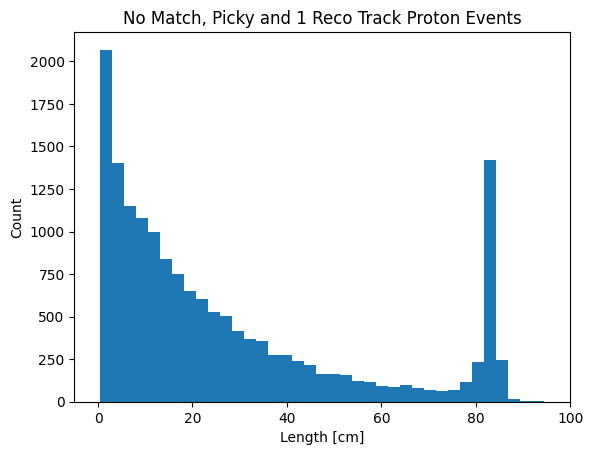

In [94]:
plt.hist(selection['trklength'], bins='auto')
plt.xlim(-5, 100)
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('No Match, Picky and 1 Reco Track Proton Events')

Text(0.5, 1.0, 'No Match, Picky and 1 Reco Track Proton Events')

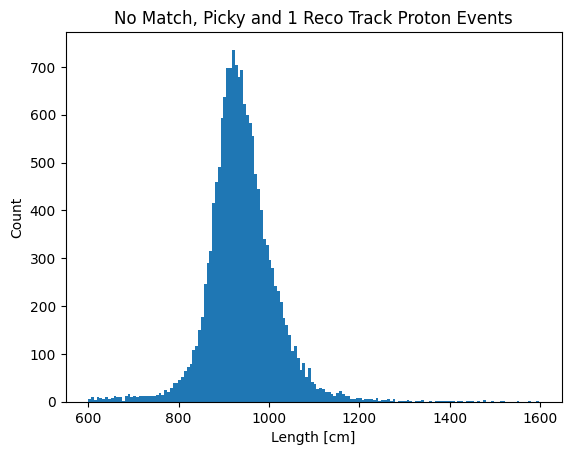

In [95]:
plt.hist(selection['beamline_mass'], bins='auto')
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('No Match, Picky and 1 Reco Track Proton Events')

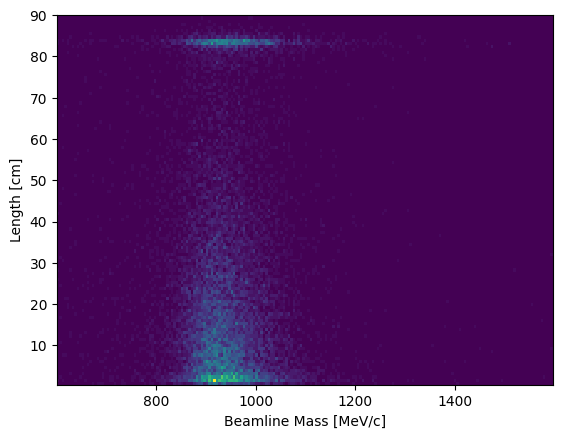

In [96]:
from matplotlib.colors import LogNorm

mass = selection['beamline_mass'].values
length = selection['trklength'].values

plt.hist2d(mass, length, bins=[200, 200]) 
plt.ylim(0.5, 90)

plt.xlabel('Beamline Mass [MeV/c]')
plt.ylabel('Length [cm]')
plt.show()

In [97]:
current = df[(df['wctrk_picky'] == 1) & (df['trkWCtoTPCMatch'] == 1) & (df['ntracks_reco'] == 1) & (df['ntracks_reco'] == 1) & (df['beamline_mass'] > 600) & (df['beamline_mass'] < 1600)]

In [72]:
min(selection['trklength'])

0.46246

In [73]:
min(current['trklength'])

4.01748

Text(0.5, 1.0, 'Match, Picky and 1 Reco Track Proton Events')

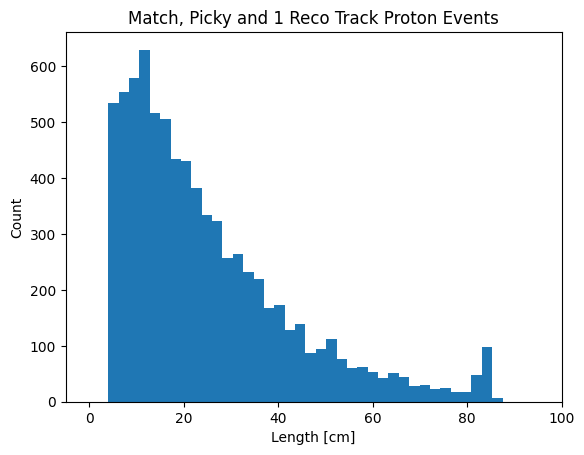

In [74]:
plt.hist(current['trklength'], bins='auto')
plt.xlim(-5, 100)
plt.xlabel('Length [cm]')
plt.ylabel('Count')
plt.title('Match, Picky and 1 Reco Track Proton Events')

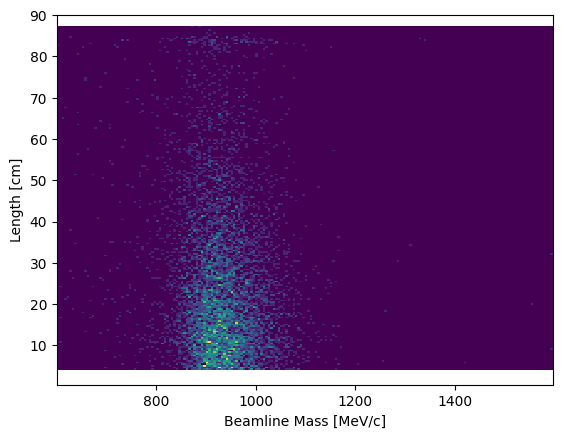

In [75]:
mass = current['beamline_mass'].values
length = current['trklength'].values

plt.hist2d(mass, length, bins=[200, 200]) 
plt.ylim(0.5, 90)

plt.xlabel('Beamline Mass [MeV/c]')
plt.ylabel('Length [cm]')
plt.show()